# Test for SEIR2_sf_reported model 
The model used in this script was stored in DENV_model_pySODM under the name JumpProcess_SEIR2_beta_by_Temp_sf_BirthDeath_reported

In [56]:
# import dependencies

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.cm as cm # to plot colors per draw
from matplotlib import gridspec

import os

import random # for the draw function from uniform distribution

# OPTIONAL: Load the "autoreload" extension so that package code can change
%load_ext autoreload
# OPTIONAL: always reload modules so that as you change code in src, it gets loaded
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [74]:
################
## Load model ##
################

from DENV_models_pySODM import JumpProcess_SEIR2_beta_by_Temp_sf_BirthDeath_reported as SEIR2
from Scaling_functions_beta_t import lambrechts_scaling, perkins_scaling_norm, mordecai_scaling_aegypti, mordecai_scaling_albopictus, seasonal_forcing_fitted
from Plot_functions import plot_variable

In [58]:
# Paths and file
file_path = "/media/rita/New Volume/Documenten/DI-MOB/Data Sharing/WP2_Meteorological_Data"
file = "Meteorologicas_2012_2022_withSE_v04102024_v1.xlsx"

# Load and preprocess the meteorological data
meteo = pd.read_excel(os.path.join(file_path, file))
meteo = meteo.drop(columns=["Canta_Rana", "Los_Jimenez", "La_Ceiba"], errors='ignore')
meteo.columns = meteo.columns.str.strip().str.replace(' ', '_').str.lower()

if 'date' not in meteo.columns:
    raise ValueError("Column 'date' not found in the dataset.")
meteo['date'] = pd.to_datetime(meteo['date'], errors='coerce')
meteo.set_index('date', inplace=True)

# Extract temperature and rainfall series
temperature_series = meteo["temp_med"]
rainfall_series = meteo["precip_ponderada"]

# Handle missing values
if temperature_series.isna().any() or rainfall_series.isna().any():
    print("Warning: Missing values detected. Filling with interpolation.")
    temperature_series = temperature_series.interpolate()
    rainfall_series = rainfall_series.interpolate()


In [59]:
def generate_scaling_factors(temperature_series, rainfall_series, dates, scaling_methods=None):
    """
    Generate scaling factors based on temperature, rainfall, and dates.
    
    Parameters:
        temperature_series (pd.Series): Time series of temperatures.
        rainfall_series (pd.Series): Time series of rainfall values.
        dates (pd.DatetimeIndex): Date indices for the time series.
        scaling_methods (list): List of scaling methods to use. Options:
                                ['mordecai_aeg', 'mordecai_albo', 'lambrechts', 'perkins', 'seasonal_forcing'].
                                If None, all methods are calculated.
                                
    Returns:
        dict: Dictionary of scaling factors, with each scaling factor formatted as a DataFrame
              with a single column named 'sf'.
    """
    available_methods = {
        'mordecai_aeg': lambda: temperature_series.apply(mordecai_scaling_aegypti),
        'mordecai_albo': lambda: temperature_series.apply(mordecai_scaling_albopictus),
        'lambrechts': lambda: temperature_series.apply(lambrechts_scaling),
        'perkins': lambda: pd.Series(
            [perkins_scaling_norm(temp, rain) for temp, rain in zip(temperature_series, rainfall_series)],
            index=temperature_series.index
        ),
        'seasonal_forcing': lambda: pd.Series(
            [seasonal_forcing_fitted(date, is_week=False) for date in dates],
            index=dates
        )
    }
    
    # get the time variable from the meteo data 
    time = temperature_series.index

    # Validate methods and calculate scaling factors
    scaling_methods = scaling_methods or available_methods.keys()
    invalid_methods = set(scaling_methods) - available_methods.keys()
    if invalid_methods:
        raise ValueError(f"Invalid scaling methods: {invalid_methods}. Available methods are: {list(available_methods.keys())}")
    
    # Calculate and format scaling factors
    scaling_factors = {
        method: available_methods[method]().to_frame(name="sf").reset_index(drop=True)
        for method in scaling_methods
    }
    
    return scaling_factors, time

In [75]:
scaling_factors, time = generate_scaling_factors(
    temperature_series=temperature_series,
    rainfall_series=rainfall_series,
    dates=temperature_series.index,
    scaling_methods= ["seasonal_forcing"]
)

print(scaling_factors['seasonal_forcing'])

# Define model parameters
params={'alpha':182.5, 'b':2.77e-05, 'd':2.45e-05, 'sigma':6, 'gamma':7, 'psi': 1.5, 'beta_0' : 0.3, 'sf' : scaling_factors['seasonal_forcing'], 'rho' : 0.10} 

# Define initial condition
initN = 200000
initI1 = 20
initI2 = 40
initS = initN - (initI1 + initI2)

initial_states = {'S': initS,
               'I1': initI1,
               'I2': initI2}

model_temp = SEIR2(initial_states=initial_states, parameters=params) 

            sf
0     0.287393
1     0.287518
2     0.287716
3     0.287988
4     0.288334
...        ...
4013  0.360665
4014  0.357606
4015  0.354604
4016  0.351659
4017  0.348773

[4018 rows x 1 columns]
I_new_new [0.66666667]

currently in I1, I2, I12, and I21 [20.] [40.] [0.] [0.]

I_reported_new [0.4]


In [79]:
n = 2
tau = 1
out_temp = model_temp.sim(time=[time[0], time[-1]], N=n, tau=tau, output_timestep=1)

I_new_new [0]

currently in I1, I2, I12, and I21 [20.] [40.] [0.] [0.]

I_reported_new [10]
I_new_new [1]

currently in I1, I2, I12, and I21 [15.] [36.] [0.] [0.]

I_reported_new [6]
I_new_new [3]

currently in I1, I2, I12, and I21 [15.] [31.] [0.] [0.]

I_reported_new [2]
I_new_new [5]

currently in I1, I2, I12, and I21 [14.] [26.] [0.] [0.]

I_reported_new [1]
I_new_new [0]

currently in I1, I2, I12, and I21 [13.] [27.] [0.] [0.]

I_reported_new [5]
I_new_new [0]

currently in I1, I2, I12, and I21 [10.] [24.] [0.] [0.]

I_reported_new [2]
I_new_new [2]

currently in I1, I2, I12, and I21 [9.] [21.] [0.] [0.]

I_reported_new [6]
I_new_new [4]

currently in I1, I2, I12, and I21 [8.] [22.] [0.] [0.]

I_reported_new [1]
I_new_new [0]

currently in I1, I2, I12, and I21 [9.] [22.] [0.] [0.]

I_reported_new [5]
I_new_new [4]

currently in I1, I2, I12, and I21 [9.] [20.] [0.] [0.]

I_reported_new [2]
I_new_new [5]

currently in I1, I2, I12, and I21 [10.] [20.] [0.] [0.]

I_reported_new [2]
I_

In [80]:
print(out_temp)
# rename coordinate 'date' to 'time' to be able to use the plotting functions

out_temp = out_temp.rename({'date': 'time'})


<xarray.Dataset> Size: 1MB
Dimensions:  (draws: 2, date: 4018)
Coordinates:
  * date     (date) datetime64[ns] 32kB 2012-01-01 2012-01-02 ... 2022-12-31
Dimensions without coordinates: draws
Data variables: (12/17)
    S        (draws, date) float64 64kB 1.999e+05 1.999e+05 ... 3.752e+04
    S1       (draws, date) float64 64kB 0.0 0.0 0.0 ... 5.405e+04 5.405e+04
    S2       (draws, date) float64 64kB 0.0 0.0 0.0 ... 8.655e+04 8.655e+04
    E1       (draws, date) float64 64kB 0.0 3.0 2.0 1.0 2.0 ... 0.0 0.0 0.0 0.0
    E2       (draws, date) float64 64kB 0.0 5.0 8.0 8.0 4.0 ... 0.0 0.0 0.0 0.0
    E12      (draws, date) float64 64kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    ...       ...
    R1       (draws, date) float64 64kB 0.0 5.0 6.0 9.0 10.0 ... 0.0 0.0 0.0 0.0
    R2       (draws, date) float64 64kB 0.0 4.0 9.0 15.0 ... 0.0 0.0 0.0 0.0
    R        (draws, date) float64 64kB 0.0 0.0 0.0 ... 8.254e+03 8.254e+03
    I_new    (draws, date) float64 64kB 0.0 0.0 1.0 3.0 5.0 ... 0.0

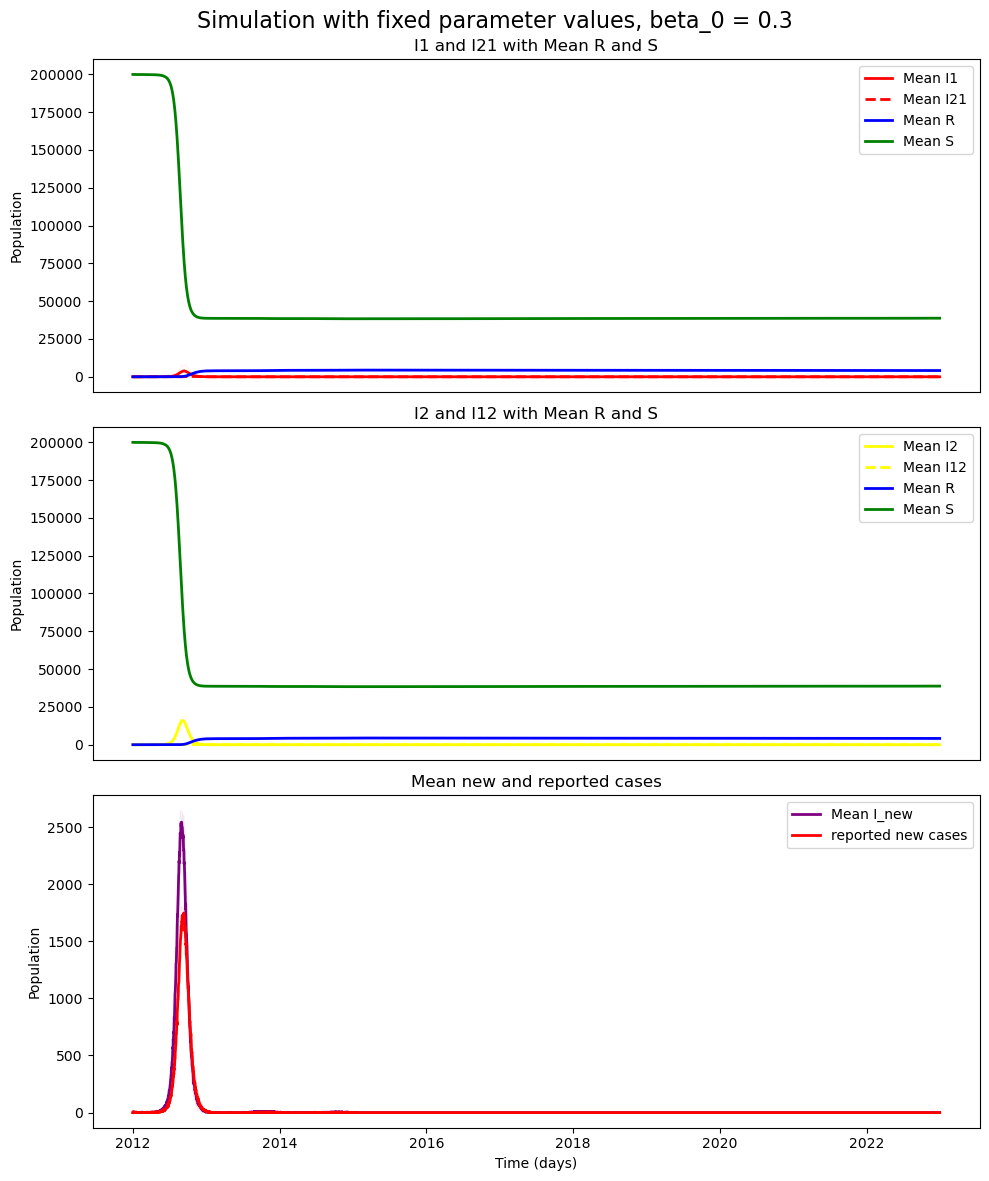

In [81]:
# Define the variables for each subplot and colors

variables_to_plot = [('I1', 'I21'), ('I2', 'I12')]  # Paired variables are to be plotted together
colors = ['red', 'yellow']  # Color for I1/I21 and I2/I12 respectively
mean_variables = ['R', 'S']
mean_colors = ['blue', 'green']

# Define cumulative and new infections variables
I_cum = out_temp['I_cum']
I_new = out_temp['I_new']

# Create a 4x1 subplot layout for the two serotype subplots plus I_new and I_cum
fig, axs = plt.subplots(3, figsize=(10, 12))

#######################################################
# Plot the two serotype subplots for I1/I21 and I2/I12
#######################################################
for i, (firstI, secondI) in enumerate(variables_to_plot):
    plot_variable(axs[i], out_temp[firstI], colors[i], f'Mean {firstI}', log=False)
    plot_variable(axs[i], out_temp[secondI], colors[i], f'Mean {secondI}', linestyle='--', log=False)
    
    # Plot R and S in the first two subplots
    for j, mean_var in enumerate(mean_variables):
        plot_variable(axs[i], out_temp[mean_var], mean_colors[j], f'Mean {mean_var}', plot_draws=False, log=False)
    
    axs[i].set_title(f'{firstI} and {secondI} with Mean R and S')


######################################
# Third subplot for I_new, and I_reported
######################################

plot_variable(axs[2], out_temp["I_new"], 'purple', 'Mean I_new', log=False)
plot_variable(axs[2], out_temp["I_rep"], 'red', 'reported new cases', log=False)
axs[2].set_title('Mean new and reported cases')
axs[2].set_xlabel('Time (days)')
axs[2].set_ylabel('Population')
axs[2].legend()

fig.suptitle(f'Simulation with fixed parameter values, beta_0 = {params['beta_0']}', fontsize=16)

for i, ax in enumerate(axs):
    if i < 2: 
        ax.set_ylabel('Population')
        ax.set_xticks([])
        ax.set_xticklabels([])
        ax.legend()
# Adjust layout and show plot
plt.tight_layout()
plt.show()

In deze aanpak is I_reported op elk moment veel groter dan 0.10*I_new. Dit is omdat er steeds 10% wordt genomen van de mensen in I en ieder persoon blijft daar een paar dagen. Dus I_reported = rho*I per soort I en dan optellen is niet de juiste aanpak. Ik denk dat ik eigenlijk 10% moet nemen op de I_new steeds. 

-> Volgende week implementeren. 